# POOD Dataset Purification EBM vs DM-DDPM

## Narcissus

### Eps 8

In [337]:
import pandas as pd
import json
import numpy as np

df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/Poison_Defense/From_Scratch/Narcissus/POOD.csv')
df['Args'] = df['Args'].apply(lambda x: json.loads(x))
df = pd.concat([df.drop(['Args'], axis=1), df['Args'].apply(pd.Series)], axis=1)

global_filters = {'noise_eps_narcissus': 8, 
                  }

# Global filters
for key, value in global_filters.items():
    df = df[df[key] == value]

# Defense filters
filters = {
            'EBM_cinic10_imagenet-150':{'Data Key': 'EBM[cinic10_imagenet_nf[32]]_Steps[150]_T[0.0001]'},
            'EBM_cifar10-150':{'Data Key': 'EBMSNGAN32[cifar10_nf[128]]_Steps[150]_T[0.0001]'},
            'EBM_office_home-150':{'Data Key': 'EBM[office_home_nf[32]]_Steps[150]_T[0.0001]'},
            'EBM_textures-150':{'Data Key': 'EBM[textures_nf[32]]_Steps[150]_T[0.0001]'},
            'EBM_lfw_people-150':{'Data Key': 'EBM[lfw_people_nf[32]]_Steps[150]_T[0.0001]'},
            'EBM_flowers102-150':{'Data Key': 'EBM[flowers102_nf[32]]_Steps[150]_T[0.0001]'},
            'DM DDPM_cifar10-150':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_cifar10-125':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_cifar10-100':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_cifar10-75':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_cinic10_imagenet-150':{'Data Key': 'DM_UNET[cinic10_imagenet_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_cinic10_imagenet-125':{'Data Key': 'DM_UNET[cinic10_imagenet_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_cinic10_imagenet-100':{'Data Key': 'DM_UNET[cinic10_imagenet_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_cinic10_imagenet-75':{'Data Key': 'DM_UNET[cinic10_imagenet_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_office_home-150':{'Data Key': 'DM_UNET[office_home_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_office_home-125':{'Data Key': 'DM_UNET[office_home_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_office_home-100':{'Data Key': 'DM_UNET[office_home_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_office_home-75':{'Data Key': 'DM_UNET[office_home_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_textures-150':{'Data Key': 'DM_UNET[textures_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_textures-125':{'Data Key': 'DM_UNET[textures_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_textures-100':{'Data Key': 'DM_UNET[textures_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_textures-75':{'Data Key': 'DM_UNET[textures_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_lfw_people-150':{'Data Key': 'DM_UNET[lfw_people_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_lfw_people-125':{'Data Key': 'DM_UNET[lfw_people_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_lfw_people-100':{'Data Key': 'DM_UNET[lfw_people_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_lfw_people-75':{'Data Key': 'DM_UNET[lfw_people_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_flowers102-150':{'Data Key': 'DM_UNET[flowers102_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_flowers102-125':{'Data Key': 'DM_UNET[flowers102_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_flowers102-100':{'Data Key': 'DM_UNET[flowers102_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_flowers102-75':{'Data Key': 'DM_UNET[flowers102_DDPM[250]_nf[L]]_T[75]'},
}

df_results = []
for label, filter_dict in filters.items():

    df_filt = df
    for key, value in filter_dict.items():
        df_filt = df_filt[df_filt[key] == value]

    df_results.append({'Defense': label,
                        'Nat Acc': df_filt['End Acc'].mean(),
                        'Nat Acc Str': f"{df_filt['End Acc'].mean():.2%}\u00B1{df_filt['End Acc'].std():.2%}",
                        'Poison Success': df_filt['P1 Acc'].mean(),
                        'Poison Success Str': f"{df_filt['P1 Acc'].mean():.2%}\u00B1{df_filt['P1 Acc'].std():.2%}",
                        'Max Poison Success': df_filt['P1 Acc'].max(),
                        'Max Poison Success Str': f"{df_filt['P1 Acc'].max():.2%}",
                        'Num Results': len(df_filt),
                    })

df_results = pd.DataFrame(df_results)
# df_results

/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_55628/3921799127.py:61: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_yticklabels(['{:,.1%}'.format(x) for x in axs[0].get_yticks()])
/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_55628/3921799127.py:81: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1].set_yticklabels(['{:,.1%}'.format(x) for x in axs[1].get_yticks()])


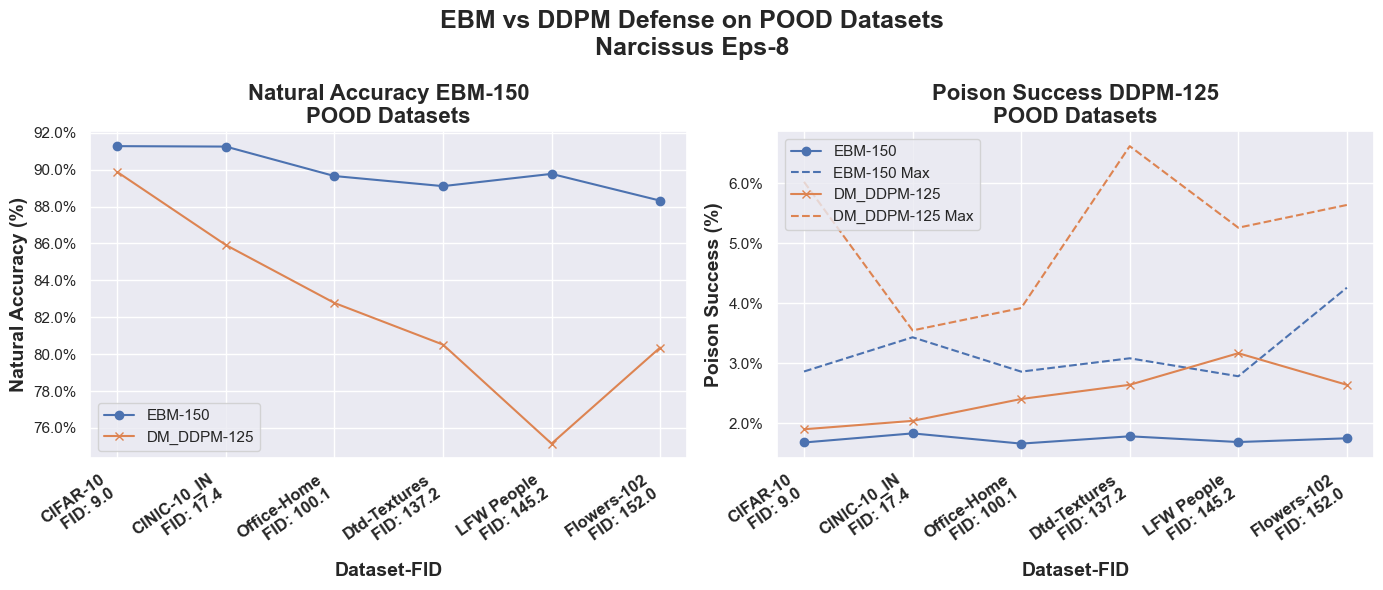

In [338]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')


dataset_dict = {
    'cifar10': 'CIFAR-10',
    'cinic10_imagenet': 'CINIC-10_IN',
    'office_home': 'Office-Home',
    'textures': 'Dtd-Textures',
    'lfw_people': 'LFW People',
    'flowers102': 'Flowers-102',
}

ebm_steps = 150
dm_steps = 125

dataset_fids = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/Poison_Defense/dataset_FIDs.csv')
dataset_fids = dataset_fids.set_index('ood_dataset')['fid_score_mean'].to_dict()

dm_plot = df_results.copy()
dm_plot['Label'] = dm_plot['Defense'].apply(lambda x: x.split('_')[0])
dm_plot['Dataset'] = dm_plot['Defense'].apply(lambda x: '_'.join(x.split('-')[0].split('_')[1:]))
dm_plot['FIDs'] = dm_plot['Dataset'].apply(lambda x: dataset_fids[x])
dm_plot['Dataset'] = dm_plot['Dataset'].apply(lambda x: dataset_dict[x])
dm_plot['Steps'] = dm_plot['Defense'].apply(lambda x: int(x.split('-')[1]) if len(x.split('-')) > 1 else 0)

# EBM Plot
dm_plot_ebm = dm_plot[(dm_plot['Steps'] == ebm_steps) & (dm_plot['Label'] == 'EBM')]
dm_plot_pivot_ebm_nat_acc = dm_plot_ebm.pivot_table(index='Label', columns=['FIDs','Dataset'], values='Nat Acc')
dm_plot_pivot_ebm_poison_acc = dm_plot_ebm.pivot_table(index='Label', columns=['FIDs','Dataset'], values='Poison Success')
dm_plot_pivot_ebm_max_poison_acc = dm_plot_ebm.pivot_table(index='Label', columns=['FIDs','Dataset'], values='Max Poison Success')
# Combine column levels into one
dm_plot_pivot_ebm_nat_acc.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in dm_plot_pivot_ebm_nat_acc.columns]
dm_plot_pivot_ebm_poison_acc.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in dm_plot_pivot_ebm_poison_acc.columns]
dm_plot_pivot_ebm_max_poison_acc.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in dm_plot_pivot_ebm_max_poison_acc.columns]

# # DM_DDPM Plot
dm_plot_dm = dm_plot[(dm_plot['Steps'] == dm_steps) & (dm_plot['Label'] == 'DM DDPM')]
dm_plot_pivot_dm_nat_acc = dm_plot_dm.pivot_table(index='Label', columns=['FIDs','Dataset'], values='Nat Acc')
dm_plot_pivot_dm_poison_acc = dm_plot_dm.pivot_table(index='Label', columns=['FIDs','Dataset'], values='Poison Success')
dm_plot_pivot_dm_max_poison_acc = dm_plot_dm.pivot_table(index='Label', columns=['FIDs','Dataset'], values='Max Poison Success')
# Combine column levels into one
dm_plot_pivot_dm_nat_acc.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in dm_plot_pivot_dm_nat_acc.columns]
dm_plot_pivot_dm_poison_acc.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in dm_plot_pivot_dm_poison_acc.columns]
dm_plot_pivot_dm_max_poison_acc.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in dm_plot_pivot_dm_max_poison_acc.columns]

fig,axs = plt.subplots(1,2,figsize=(14,6))

# Axs 0 : Natural Accuracy
axs[0].plot(dm_plot_pivot_ebm_nat_acc.columns, dm_plot_pivot_ebm_nat_acc.values[0], marker='o', label=f'EBM-{ebm_steps}')
axs[0].plot(dm_plot_pivot_dm_nat_acc.columns, dm_plot_pivot_dm_nat_acc.values[0], marker='x', label=f'DM_DDPM-{dm_steps}')

# Rotate X labels
axs[0].set_xticks(np.arange(len(dm_plot_pivot_ebm_nat_acc.columns)))
axs[0].set_xticklabels(dm_plot_pivot_ebm_nat_acc.columns, rotation=35, ha='right',fontweight='bold',fontsize=12)
axs[0].set_ylabel('Natural Accuracy (%)',fontweight='bold',fontsize=14)
axs[0].set_xlabel('Dataset-FID',fontweight='bold',fontsize=14)
axs[0].set_title('Natural Accuracy EBM-150\nPOOD Datasets',fontweight='bold',fontsize=16)
axs[0].legend()
axs[0].set_yticklabels(['{:,.1%}'.format(x) for x in axs[0].get_yticks()])

# Axs 1 : Poison Success
axs[1].plot(dm_plot_pivot_ebm_poison_acc.columns, dm_plot_pivot_ebm_poison_acc.values[0], marker='o', label=f'EBM-{ebm_steps}')
# get color of last line
color = axs[1].get_lines()[-1].get_color()
axs[1].plot(dm_plot_pivot_ebm_max_poison_acc.columns, dm_plot_pivot_ebm_max_poison_acc.values[0], '--', label=f'EBM-{ebm_steps} Max', color=color)  
axs[1].plot(dm_plot_pivot_dm_poison_acc.columns, dm_plot_pivot_dm_poison_acc.values[0], marker='x', label=f'DM_DDPM-{dm_steps}')
# get color of last line
color = axs[1].get_lines()[-1].get_color()
axs[1].plot(dm_plot_pivot_dm_max_poison_acc.columns, dm_plot_pivot_dm_max_poison_acc.values[0], '--', label=f'DM_DDPM-{dm_steps} Max', color=color)


# Rotate X labels
axs[1].set_xticks(np.arange(len(dm_plot_pivot_ebm_poison_acc.columns)))
axs[1].set_xticklabels(dm_plot_pivot_ebm_poison_acc.columns, rotation=35, ha='right',fontweight='bold',fontsize=12)
axs[1].set_ylabel('Poison Success (%)',fontweight='bold',fontsize=14)
axs[1].set_xlabel('Dataset-FID',fontweight='bold',fontsize=14)
axs[1].set_title('Poison Success DDPM-125\nPOOD Datasets',fontweight='bold',fontsize=16)
axs[1].legend()
axs[1].set_yticklabels(['{:,.1%}'.format(x) for x in axs[1].get_yticks()])


fig.suptitle('EBM vs DDPM Defense on POOD Datasets\nNarcissus Eps-8',fontweight='bold',fontsize=18)
fig.tight_layout()

# plt.savefig('EBM_vs_DDPM_POOD_Narcissus_Eps8.pdf', bbox_inches='tight')

In [305]:
dm_table = dm_plot[((dm_plot['Steps'] == ebm_steps) & (dm_plot['Label'] == 'EBM')) | ((dm_plot['Steps'] == dm_steps) & (dm_plot['Label'] == 'DM DDPM'))]
pivot_table = dm_table.pivot_table(index='Label', columns=['Dataset','FIDs'], values=['Nat Acc Str','Poison Success Str','Max Poison Success Str'],aggfunc=lambda x: ' '.join(x))
                                                                                      # print(pivot_table.to_latex(float_format="%.2f"))
print(pivot_table.to_latex(float_format="%.2f"))

\begin{tabular}{lllllllllllllllllll}
\toprule
{} & \multicolumn{6}{l}{Max Poison Success Str} & \multicolumn{6}{l}{Nat Acc Str} & \multicolumn{6}{l}{Poison Success Str} \\
Dataset &               CIFAR-10 & CINIC-10\_IN & Dtd-Textures & Flowers-102 & LFW People & Office-Home &      CIFAR-10 &   CINIC-10\_IN &  Dtd-Textures &   Flowers-102 &    LFW People &   Office-Home &           CIFAR-10 &  CINIC-10\_IN & Dtd-Textures &  Flowers-102 &   LFW People &  Office-Home \\
FIDs &             8.961049   &  17.412045  &   137.228145 &  152.017876 & 145.232817 &  100.099419 &    8.961049   &    17.412045  &    137.228145 &    152.017876 &    145.232817 &    100.099419 &         8.961049   &   17.412045  &   137.228145 &   152.017876 &   145.232817 &   100.099419 \\
Label   &                        &             &              &             &            &             &               &               &               &               &               &               &                    &           

/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_55628/1950710422.py:4: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(pivot_table.to_latex(float_format="%.2f"))


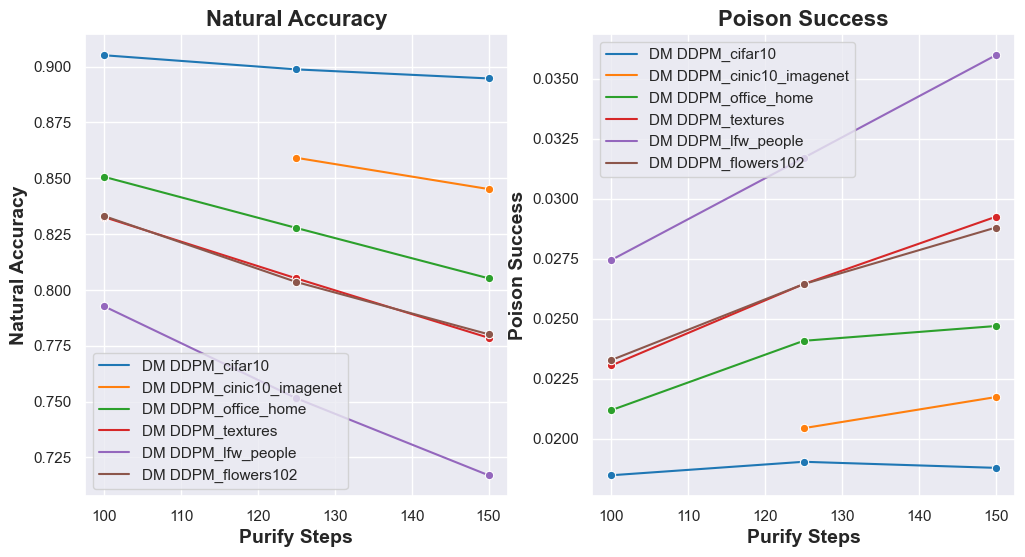

In [271]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

# Filter for EBM or DM
dm_plot = df_results[df_results['Defense'].str.contains('DM')]
dm_plot['Label'] = dm_plot['Defense'].apply(lambda x: x.split('-')[0])
dm_plot['Steps'] = dm_plot['Defense'].apply(lambda x: int(x.split('-')[1]) if len(x.split('-')) > 1 else 0)

# Filter out 0 steps
dm_plot_diff = dm_plot[dm_plot['Steps'] != 0]

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
sns.lineplot(data=dm_plot, x='Steps', y='Nat Acc', hue='Label', marker='o',palette='tab10', ax=axs[0])
sns.lineplot(data=dm_plot, x='Steps', y='Poison Success', hue='Label', marker='o',palette='tab10', ax=axs[1])

axs[0].set_title('Natural Accuracy', fontsize=16, fontweight='bold')
axs[0].set_xlabel('Purify Steps', fontsize=14, fontweight='bold')
axs[0].set_ylabel('Natural Accuracy', fontsize=14, fontweight='bold')
axs[0].legend()

axs[1].set_title('Poison Success', fontsize=16, fontweight='bold')
axs[1].set_xlabel('Purify Steps', fontsize=14, fontweight='bold')
axs[1].set_ylabel('Poison Success', fontsize=14, fontweight='bold')
axs[1].legend()

### Eps 16

In [341]:
import pandas as pd
import json
import numpy as np

df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/Poison_Defense/From_Scratch/Narcissus/POOD.csv')
df['Args'] = df['Args'].apply(lambda x: json.loads(x))
df = pd.concat([df.drop(['Args'], axis=1), df['Args'].apply(pd.Series)], axis=1)

global_filters = {'noise_eps_narcissus': 16, 
                  }

# Global filters
for key, value in global_filters.items():
    df = df[df[key] == value]

# Defense filters
filters = {
            'EBM_cinic10_imagenet-2000':{'Data Key': 'EBM[cinic10_imagenet_nf[32]]_Steps[2000]_T[0.0001]'},
            'EBM_cinic10_imagenet-1000':{'Data Key': 'EBM[cinic10_imagenet_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_cinic10_imagenet-750':{'Data Key': 'EBM[cinic10_imagenet_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_cifar10-2000':{'Data Key': 'EBMSNGAN32[cifar10_nf[128]]_Steps[2000]_T[0.0001]'},
            'EBM_cifar10-1000':{'Data Key': 'EBMSNGAN32[cifar10_nf[128]]_Steps[1000]_T[0.0001]'},
            'EBM_cifar10-750':{'Data Key': 'EBMSNGAN32[cifar10_nf[128]]_Steps[750]_T[0.0001]'},
            'EBM_office_home-2000':{'Data Key': 'EBM[office_home_nf[32]]_Steps[2000]_T[0.0001]'},
            'EBM_office_home-1000':{'Data Key': 'EBM[office_home_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_office_home-750':{'Data Key': 'EBM[office_home_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_textures-2000':{'Data Key': 'EBM[textures_nf[32]]_Steps[2000]_T[0.0001]'},
            'EBM_textures-1000':{'Data Key': 'EBM[textures_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_textures-750':{'Data Key': 'EBM[textures_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_lfw_people-2000':{'Data Key': 'EBM[lfw_people_nf[32]]_Steps[2000]_T[0.0001]'},
            'EBM_lfw_people-1000':{'Data Key': 'EBM[lfw_people_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_lfw_people-750':{'Data Key': 'EBM[lfw_people_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_flowers102-2000':{'Data Key': 'EBM[flowers102_nf[32]]_Steps[2000]_T[0.0001]'},
            'EBM_flowers102-1000':{'Data Key': 'EBM[flowers102_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_flowers102-750':{'Data Key': 'EBM[flowers102_nf[32]]_Steps[750]_T[0.0001]'},
            'DM DDPM_cifar10-150':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_cifar10-125':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_cifar10-100':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_cifar10-75':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_cinic10_imagenet-150':{'Data Key': 'DM_UNET[cinic10_imagenet_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_cinic10_imagenet-125':{'Data Key': 'DM_UNET[cinic10_imagenet_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_cinic10_imagenet-100':{'Data Key': 'DM_UNET[cinic10_imagenet_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_cinic10_imagenet-75':{'Data Key': 'DM_UNET[cinic10_imagenet_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_office_home-150':{'Data Key': 'DM_UNET[office_home_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_office_home-125':{'Data Key': 'DM_UNET[office_home_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_office_home-100':{'Data Key': 'DM_UNET[office_home_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_office_home-75':{'Data Key': 'DM_UNET[office_home_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_textures-150':{'Data Key': 'DM_UNET[textures_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_textures-125':{'Data Key': 'DM_UNET[textures_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_textures-100':{'Data Key': 'DM_UNET[textures_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_textures-75':{'Data Key': 'DM_UNET[textures_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_lfw_people-150':{'Data Key': 'DM_UNET[lfw_people_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_lfw_people-125':{'Data Key': 'DM_UNET[lfw_people_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_lfw_people-100':{'Data Key': 'DM_UNET[lfw_people_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_lfw_people-75':{'Data Key': 'DM_UNET[lfw_people_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_flowers102-150':{'Data Key': 'DM_UNET[flowers102_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_flowers102-125':{'Data Key': 'DM_UNET[flowers102_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_flowers102-100':{'Data Key': 'DM_UNET[flowers102_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_flowers102-75':{'Data Key': 'DM_UNET[flowers102_DDPM[250]_nf[L]]_T[75]'},
}

df_results = []
for label, filter_dict in filters.items():

    df_filt = df
    for key, value in filter_dict.items():
        df_filt = df_filt[df_filt[key] == value]

    df_results.append({'Defense': label,
                        'Nat Acc': df_filt['End Acc'].mean(),
                        'Nat Acc Str': f"{df_filt['End Acc'].mean():.2%}\u00B1{df_filt['End Acc'].std():.2%}",
                        'Poison Success': df_filt['P1 Acc'].mean(),
                        'Poison Success Str': f"{df_filt['P1 Acc'].mean():.2%}\u00B1{df_filt['P1 Acc'].std():.2%}",
                        'Max Poison Success': df_filt['P1 Acc'].max(),
                        'Max Poison Success Str': f"{df_filt['P1 Acc'].max():.2%}",
                        'Num Results': len(df_filt),
                    })

df_results = pd.DataFrame(df_results)
# df_results

/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_55628/1066509134.py:61: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_yticklabels(['{:,.1%}'.format(x) for x in axs[0].get_yticks()])
/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_55628/1066509134.py:81: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1].set_yticklabels(['{:,.1%}'.format(x) for x in axs[1].get_yticks()])


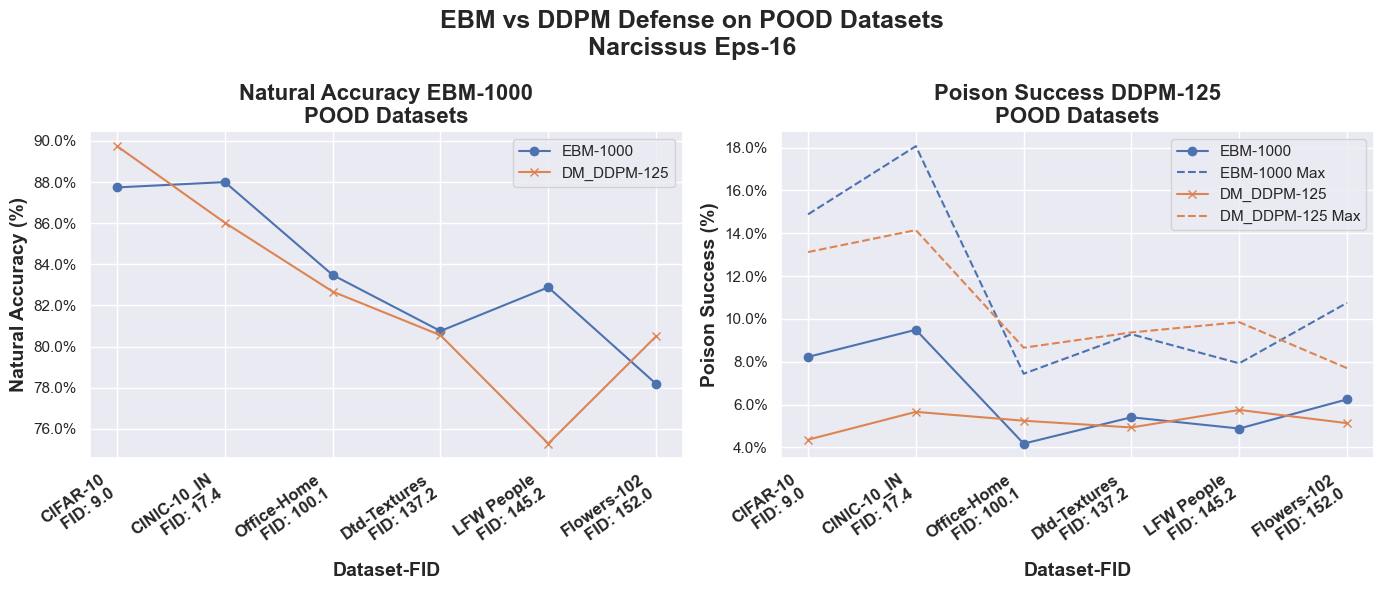

In [342]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')


dataset_dict = {
    'cifar10': 'CIFAR-10',
    'cinic10_imagenet': 'CINIC-10_IN',
    'office_home': 'Office-Home',
    'textures': 'Dtd-Textures',
    'lfw_people': 'LFW People',
    'flowers102': 'Flowers-102',
}

ebm_steps = 1000
dm_steps = 125

dataset_fids = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/Poison_Defense/dataset_FIDs.csv')
dataset_fids = dataset_fids.set_index('ood_dataset')['fid_score_mean'].to_dict()

dm_plot = df_results.copy()
dm_plot['Label'] = dm_plot['Defense'].apply(lambda x: x.split('_')[0])
dm_plot['Dataset'] = dm_plot['Defense'].apply(lambda x: '_'.join(x.split('-')[0].split('_')[1:]))
dm_plot['FIDs'] = dm_plot['Dataset'].apply(lambda x: dataset_fids[x])
dm_plot['Dataset'] = dm_plot['Dataset'].apply(lambda x: dataset_dict[x])
dm_plot['Steps'] = dm_plot['Defense'].apply(lambda x: int(x.split('-')[1]) if len(x.split('-')) > 1 else 0)

# EBM Plot
dm_plot_ebm = dm_plot[(dm_plot['Steps'] == ebm_steps) & (dm_plot['Label'] == 'EBM')]
dm_plot_pivot_ebm_nat_acc = dm_plot_ebm.pivot_table(index='Label', columns=['FIDs','Dataset'], values='Nat Acc')
dm_plot_pivot_ebm_poison_acc = dm_plot_ebm.pivot_table(index='Label', columns=['FIDs','Dataset'], values='Poison Success')
dm_plot_pivot_ebm_max_poison_acc = dm_plot_ebm.pivot_table(index='Label', columns=['FIDs','Dataset'], values='Max Poison Success')
# Combine column levels into one
dm_plot_pivot_ebm_nat_acc.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in dm_plot_pivot_ebm_nat_acc.columns]
dm_plot_pivot_ebm_poison_acc.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in dm_plot_pivot_ebm_poison_acc.columns]
dm_plot_pivot_ebm_max_poison_acc.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in dm_plot_pivot_ebm_max_poison_acc.columns]

# # DM_DDPM Plot
dm_plot_dm = dm_plot[(dm_plot['Steps'] == dm_steps) & (dm_plot['Label'] == 'DM DDPM')]
dm_plot_pivot_dm_nat_acc = dm_plot_dm.pivot_table(index='Label', columns=['FIDs','Dataset'], values='Nat Acc')
dm_plot_pivot_dm_poison_acc = dm_plot_dm.pivot_table(index='Label', columns=['FIDs','Dataset'], values='Poison Success')
dm_plot_pivot_dm_max_poison_acc = dm_plot_dm.pivot_table(index='Label', columns=['FIDs','Dataset'], values='Max Poison Success')
# Combine column levels into one
dm_plot_pivot_dm_nat_acc.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in dm_plot_pivot_dm_nat_acc.columns]
dm_plot_pivot_dm_poison_acc.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in dm_plot_pivot_dm_poison_acc.columns]
dm_plot_pivot_dm_max_poison_acc.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in dm_plot_pivot_dm_max_poison_acc.columns]

fig,axs = plt.subplots(1,2,figsize=(14,6))

# Axs 0 : Natural Accuracy
axs[0].plot(dm_plot_pivot_ebm_nat_acc.columns, dm_plot_pivot_ebm_nat_acc.values[0], marker='o', label=f'EBM-{ebm_steps}')
axs[0].plot(dm_plot_pivot_dm_nat_acc.columns, dm_plot_pivot_dm_nat_acc.values[0], marker='x', label=f'DM_DDPM-{dm_steps}')

# Rotate X labels
axs[0].set_xticks(np.arange(len(dm_plot_pivot_ebm_nat_acc.columns)))
axs[0].set_xticklabels(dm_plot_pivot_ebm_nat_acc.columns, rotation=35, ha='right',fontweight='bold',fontsize=12)
axs[0].set_ylabel('Natural Accuracy (%)',fontweight='bold',fontsize=14)
axs[0].set_xlabel('Dataset-FID',fontweight='bold',fontsize=14)
axs[0].set_title(f'Natural Accuracy EBM-{ebm_steps}\nPOOD Datasets',fontweight='bold',fontsize=16)
axs[0].legend()
axs[0].set_yticklabels(['{:,.1%}'.format(x) for x in axs[0].get_yticks()])

# Axs 1 : Poison Success
axs[1].plot(dm_plot_pivot_ebm_poison_acc.columns, dm_plot_pivot_ebm_poison_acc.values[0], marker='o', label=f'EBM-{ebm_steps}')
# get color of last line
color = axs[1].get_lines()[-1].get_color()
axs[1].plot(dm_plot_pivot_ebm_max_poison_acc.columns, dm_plot_pivot_ebm_max_poison_acc.values[0], '--', label=f'EBM-{ebm_steps} Max', color=color)  
axs[1].plot(dm_plot_pivot_dm_poison_acc.columns, dm_plot_pivot_dm_poison_acc.values[0], marker='x', label=f'DM_DDPM-{dm_steps}')
# get color of last line
color = axs[1].get_lines()[-1].get_color()
axs[1].plot(dm_plot_pivot_dm_max_poison_acc.columns, dm_plot_pivot_dm_max_poison_acc.values[0], '--', label=f'DM_DDPM-{dm_steps} Max', color=color)


# Rotate X labels
axs[1].set_xticks(np.arange(len(dm_plot_pivot_ebm_poison_acc.columns)))
axs[1].set_xticklabels(dm_plot_pivot_ebm_poison_acc.columns, rotation=35, ha='right',fontweight='bold',fontsize=12)
axs[1].set_ylabel('Poison Success (%)',fontweight='bold',fontsize=14)
axs[1].set_xlabel('Dataset-FID',fontweight='bold',fontsize=14)
axs[1].set_title(f'Poison Success DDPM-{dm_steps}\nPOOD Datasets',fontweight='bold',fontsize=16)
axs[1].legend()
axs[1].set_yticklabels(['{:,.1%}'.format(x) for x in axs[1].get_yticks()])


fig.suptitle('EBM vs DDPM Defense on POOD Datasets\nNarcissus Eps-16',fontweight='bold',fontsize=18)
fig.tight_layout()

plt.savefig('EBM_vs_DDPM_POOD_Narcissus_Eps16.pdf', bbox_inches='tight')

In [343]:
dm_table = dm_plot[((dm_plot['Steps'] == ebm_steps) & (dm_plot['Label'] == 'EBM')) | ((dm_plot['Steps'] == dm_steps) & (dm_plot['Label'] == 'DM DDPM'))]
pivot_table = dm_table.pivot_table(index='Label', columns=['Dataset','FIDs'], values=['Nat Acc Str','Poison Success Str','Max Poison Success Str'],aggfunc=lambda x: ' '.join(x))
                                                                                      # print(pivot_table.to_latex(float_format="%.2f"))
pivot_table

Max Poison Success Str                                       \
Dataset               CIFAR-10 CINIC-10_IN Dtd-Textures Flowers-102   
FIDs                8.961049    17.412045    137.228145  152.017876   
Label                                                                 
DM DDPM                 13.12%      14.15%        9.37%       7.70%   
EBM                     14.88%      18.06%        9.28%      10.75%   

                                 Nat Acc Str                              \
Dataset LFW People Office-Home      CIFAR-10   CINIC-10_IN  Dtd-Textures   
FIDs    145.232817  100.099419    8.961049      17.412045     137.228145   
Label                                                                      
DM DDPM      9.85%       8.66%  89.75%±0.17%  86.03%±0.22%  80.55%±0.31%   
EBM          7.93%       7.44%  87.74%±0.32%  88.00%±0.34%  80.76%±0.28%   

                                                  Poison Success Str  \
Dataset   Flowers-102    LFW People   Office-Home           CIFAR-10   
FIDs       152.017876    145.232817    100.099419         8.961049     
Label                                                                  
DM DDPM  80.50%±0.21%  75.28%±0.33%  82.68%±0.21%        4.36%±3.63%   
EBM      78.19%±0.22%  82.88%±0.23%  83.48%±0.16%        8.23%±4.64%   

                                                                          
Dataset  CINIC-10_IN Dtd-Textures  Flowers-102   LFW People  Office-Home  
FIDs      17.412045    137.228145   152.017876   145.232817   100.099419  
Label                                                                     
DM DDPM  5.66%±3.94%  4.93%±2.23%  5.13%±2.04%  5.75%±2.31%  5.25%±2.68%  
EBM      9.49%±5.69%  5.41%±2.56%  6.24%±2.53%  4.88%±1.97%  4.18%±2.12%

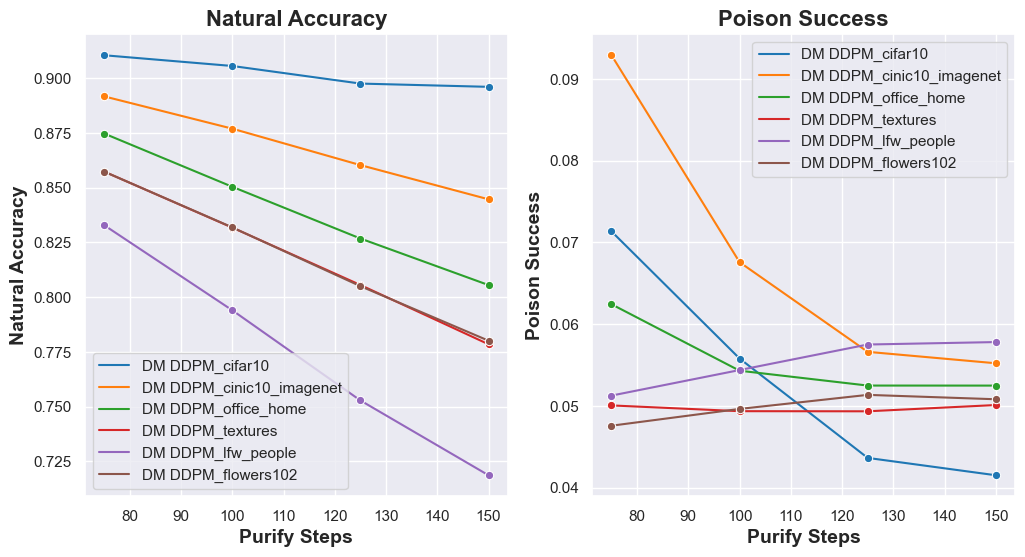

In [333]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

# Filter for EBM or DM
dm_plot = df_results[df_results['Defense'].str.contains('DM')]
dm_plot['Label'] = dm_plot['Defense'].apply(lambda x: x.split('-')[0])
dm_plot['Steps'] = dm_plot['Defense'].apply(lambda x: int(x.split('-')[1]) if len(x.split('-')) > 1 else 0)

# Filter out 0 steps
dm_plot_diff = dm_plot[dm_plot['Steps'] != 0]

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
sns.lineplot(data=dm_plot, x='Steps', y='Nat Acc', hue='Label', marker='o',palette='tab10', ax=axs[0])
sns.lineplot(data=dm_plot, x='Steps', y='Poison Success', hue='Label', marker='o',palette='tab10', ax=axs[1])

axs[0].set_title('Natural Accuracy', fontsize=16, fontweight='bold')
axs[0].set_xlabel('Purify Steps', fontsize=14, fontweight='bold')
axs[0].set_ylabel('Natural Accuracy', fontsize=14, fontweight='bold')
axs[0].legend()

axs[1].set_title('Poison Success', fontsize=16, fontweight='bold')
axs[1].set_xlabel('Purify Steps', fontsize=14, fontweight='bold')
axs[1].set_ylabel('Poison Success', fontsize=14, fontweight='bold')
axs[1].legend()

## Neural Tangent

In [314]:
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import json
import numpy as np

df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/Poison_Defense/From_Scratch/NeuralTangent/POOD.csv')

filters = {
            # 'Baseline':{'Data Key': 'Baseline'},
            # 'JPEG_25':{'Data Key': 'JPEG[25]'},
            'EBM_cinic10_imagenet-1000':{'Data Key': 'EBM[cinic10_imagenet_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_cinic10_imagenet-750':{'Data Key': 'EBM[cinic10_imagenet_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_cinic10_imagenet-500':{'Data Key': 'EBM[cinic10_imagenet_nf[32]]_Steps[500]_T[0.0001]'},
            'EBM_cinic10_imagenet-150':{'Data Key': 'EBM[cinic10_imagenet_nf[32]]_Steps[150]_T[0.0001]'},
            'EBM_cifar10-1000':{'Data Key': 'EBMSNGAN32[cifar10_nf[128]]_Steps[1000]_T[0.0001]'},
            'EBM_cifar10-750':{'Data Key': 'EBMSNGAN32[cifar10_nf[128]]_Steps[750]_T[0.0001]'},
            'EBM_cifar10-500':{'Data Key': 'EBMSNGAN32[cifar10_nf[128]]_Steps[500]_T[0.0001]'},
            'EBM_cifar10-150':{'Data Key': 'EBMSNGAN32[cifar10_nf[128]]_Steps[150]_T[0.0001]'},
            'EBM_office_home-1000':{'Data Key': 'EBM[office_home_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_office_home-750':{'Data Key': 'EBM[office_home_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_office_home-500':{'Data Key': 'EBM[office_home_nf[32]]_Steps[500]_T[0.0001]'},
            'EBM_office_home-150':{'Data Key': 'EBM[office_home_nf[32]]_Steps[150]_T[0.0001]'},
            'EBM_textures-1000':{'Data Key': 'EBM[textures_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_textures-750':{'Data Key': 'EBM[textures_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_textures-500':{'Data Key': 'EBM[textures_nf[32]]_Steps[500]_T[0.0001]'},
            'EBM_textures-150':{'Data Key': 'EBM[textures_nf[32]]_Steps[150]_T[0.0001]'},
            'EBM_lfw_people-1000':{'Data Key': 'EBM[lfw_people_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_lfw_people-750':{'Data Key': 'EBM[lfw_people_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_lfw_people-500':{'Data Key': 'EBM[lfw_people_nf[32]]_Steps[500]_T[0.0001]'},
            'EBM_lfw_people-150':{'Data Key': 'EBM[lfw_people_nf[32]]_Steps[150]_T[0.0001]'},
            'EBM_flowers102-1000':{'Data Key': 'EBM[flowers102_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_flowers102-750':{'Data Key': 'EBM[flowers102_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_flowers102-500':{'Data Key': 'EBM[flowers102_nf[32]]_Steps[500]_T[0.0001]'},
            'EBM_flowers102-150':{'Data Key': 'EBM[flowers102_nf[32]]_Steps[150]_T[0.0001]'},
            'DM DDPM_cifar10-150':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_cifar10-125':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_cifar10-100':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_cifar10-75':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_cinic10_imagenet-150':{'Data Key': 'DM_UNET[cinic10_imagenet_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_cinic10_imagenet-125':{'Data Key': 'DM_UNET[cinic10_imagenet_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_cinic10_imagenet-100':{'Data Key': 'DM_UNET[cinic10_imagenet_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_cinic10_imagenet-75':{'Data Key': 'DM_UNET[cinic10_imagenet_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_office_home-150':{'Data Key': 'DM_UNET[office_home_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_office_home-125':{'Data Key': 'DM_UNET[office_home_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_office_home-100':{'Data Key': 'DM_UNET[office_home_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_office_home-75':{'Data Key': 'DM_UNET[office_home_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_textures-150':{'Data Key': 'DM_UNET[textures_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_textures-125':{'Data Key': 'DM_UNET[textures_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_textures-100':{'Data Key': 'DM_UNET[textures_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_textures-75':{'Data Key': 'DM_UNET[textures_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_lfw_people-150':{'Data Key': 'DM_UNET[lfw_people_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_lfw_people-125':{'Data Key': 'DM_UNET[lfw_people_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_lfw_people-100':{'Data Key': 'DM_UNET[lfw_people_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_lfw_people-75':{'Data Key': 'DM_UNET[lfw_people_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_flowers102-150':{'Data Key': 'DM_UNET[flowers102_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_flowers102-125':{'Data Key': 'DM_UNET[flowers102_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_flowers102-100':{'Data Key': 'DM_UNET[flowers102_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_flowers102-75':{'Data Key': 'DM_UNET[flowers102_DDPM[250]_nf[L]]_T[75]'},
}

df_results = []
for label, filter_dict in filters.items():

    df_filt = df
    for key, value in filter_dict.items():
        if value == 'NaN':
            df_filt = df_filt[df_filt[key].isnull()]
        else:
            df_filt = df_filt[df_filt[key] == value]


    df_results.append({'Defense': label,
                        'Nat Acc': f"{df_filt['End Acc'].mean()*100:.2f} \u00B1 {df_filt['End Acc'].std()*100:.2f}",
                        'Nat Acc Str': f"{df_filt['End Acc'].mean():.2%}\u00B1{df_filt['End Acc'].std():.2%}",
                    'Num Results': len(df_filt),
                    })
        
df_results = pd.DataFrame(df_results)
# df_results

/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_55628/379648916.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.1%}'.format(x/100) for x in plt.gca().get_yticks()])


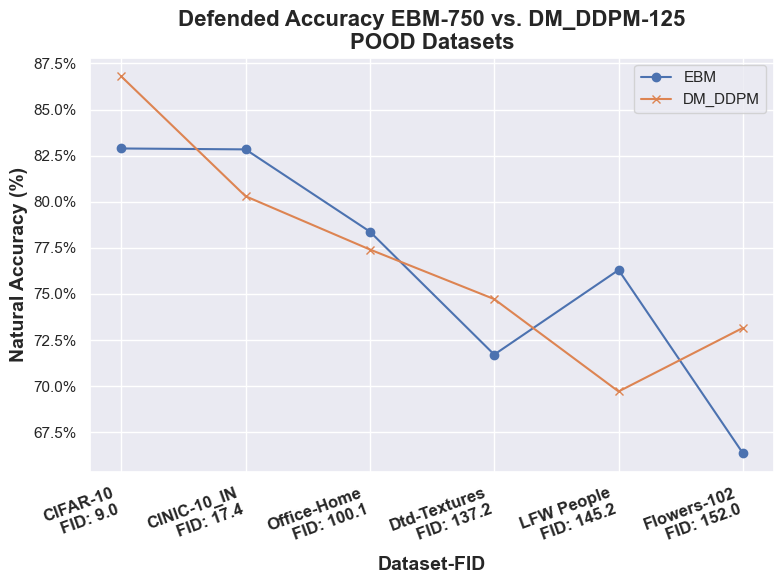

In [315]:
dataset_dict = {
    'cifar10': 'CIFAR-10',
    'cinic10_imagenet': 'CINIC-10_IN',
    'office_home': 'Office-Home',
    'textures': 'Dtd-Textures',
    'lfw_people': 'LFW People',
    'flowers102': 'Flowers-102',
}

dataset_fids = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/Poison_Defense/dataset_FIDs.csv')
dataset_fids = dataset_fids.set_index('ood_dataset')['fid_score_mean'].to_dict()

dm_plot = df_results.copy()
dm_plot['Label'] = dm_plot['Defense'].apply(lambda x: x.split('_')[0])
dm_plot['Dataset'] = dm_plot['Defense'].apply(lambda x: '_'.join(x.split('-')[0].split('_')[1:]))
dm_plot['FIDs'] = dm_plot['Dataset'].apply(lambda x: dataset_fids[x])
dm_plot['Dataset'] = dm_plot['Dataset'].apply(lambda x: dataset_dict[x])
dm_plot['Steps'] = dm_plot['Defense'].apply(lambda x: int(x.split('-')[1]) if len(x.split('-')) > 1 else 0)
dm_plot['Nat Acc Mean'] = dm_plot['Nat Acc'].apply(lambda x: float(x.split(' ')[0]))

# EBM Plot
dm_plot_ebm = dm_plot[(dm_plot['Steps'] == 750) & (dm_plot['Label'] == 'EBM')]
dm_plot_pivot_ebm = dm_plot_ebm.pivot_table(index='Label', columns=['FIDs','Dataset'], values='Nat Acc Mean')
# Combine column levels into one
dm_plot_pivot_ebm.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in dm_plot_pivot_ebm.columns]

# DM_DDPM Plot
dm_plot_dm = dm_plot[(dm_plot['Steps'] == 125) & (dm_plot['Label'] == 'DM DDPM')]
dm_plot_pivot_dm = dm_plot_dm.pivot_table(index='Label', columns=['FIDs','Dataset'], values='Nat Acc Mean')
# Combine column levels into one
dm_plot_pivot_dm.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in dm_plot_pivot_dm.columns]


# Replace X labels with f'{Dataset}-FID:{FID}'
plt.figure(figsize=(8,6))
plt.plot(dm_plot_pivot_ebm.columns, dm_plot_pivot_ebm.values[0], marker='o', label='EBM')
plt.plot(dm_plot_pivot_dm.columns, dm_plot_pivot_dm.values[0], marker='x', label='DM_DDPM')
# Roate X labels
plt.xticks(rotation=20, ha='right',fontweight='bold',fontsize=12)
plt.ylabel('Natural Accuracy (%)',fontweight='bold',fontsize=14)
plt.xlabel('Dataset-FID',fontweight='bold',fontsize=14)
plt.title('Defended Accuracy EBM-750 vs. DM_DDPM-125\nPOOD Datasets',fontweight='bold',fontsize=16)
plt.legend() 
# Set y-axis to percentage
plt.gca().set_yticklabels(['{:,.1%}'.format(x/100) for x in plt.gca().get_yticks()])

plt.tight_layout()
plt.savefig('EBM_vs_DDPM_POOD_NeuralTangent.pdf', bbox_inches='tight')

In [316]:
dm_table = dm_plot[((dm_plot['Steps'] == 750) & (dm_plot['Label'] == 'EBM')) | ((dm_plot['Steps'] == 125) & (dm_plot['Label'] == 'DM DDPM'))]
pivot_table = dm_table.pivot_table(index='Label', columns=['Dataset','FIDs'], values=['Nat Acc Str'],aggfunc=lambda x: ' '.join(x))
print(pivot_table.to_latex(float_format="%.2f"))

\begin{tabular}{lllllll}
\toprule
{} & \multicolumn{6}{l}{Nat Acc Str} \\
Dataset &      CIFAR-10 &   CINIC-10\_IN &  Dtd-Textures &   Flowers-102 &    LFW People &   Office-Home \\
FIDs &    8.961049   &    17.412045  &    137.228145 &    152.017876 &    145.232817 &    100.099419 \\
Label   &               &               &               &               &               &               \\
\midrule
DM DDPM &  86.80\%±0.20\% &  80.30\%±0.19\% &  74.72\%±0.35\% &  73.16\%±0.42\% &  69.71\%±0.46\% &  77.41\%±0.35\% \\
EBM     &  82.89\%±0.34\% &  82.84\%±0.32\% &  71.71\%±0.33\% &  66.36\%±0.55\% &  76.30\%±0.50\% &  78.38\%±0.18\% \\
\bottomrule
\end{tabular}



/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_55628/1195019518.py:3: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(pivot_table.to_latex(float_format="%.2f"))


In [318]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

# Filter for EBM or DM
dm_plot = df_results[df_results['Defense'].str.contains('EBM')]
dm_plot['Label'] = dm_plot['Defense'].apply(lambda x: x.split('-')[0])
dm_plot['Steps'] = dm_plot['Defense'].apply(lambda x: int(x.split('-')[1]) if len(x.split('-')) > 1 else 0)
dm_plot['Nat Acc Mean'] = dm_plot['Nat Acc'].apply(lambda x: float(x.split(' ')[0]))

# Filter out 0 steps
dm_plot_diff = dm_plot[dm_plot['Steps'] != 0]

# PLot x_axis steps, y axis Nat Acc, and hue as Label
plt.figure(figsize=(12, 6))
sns.lineplot(data=dm_plot_diff, x='Steps', y='Nat Acc Mean', hue='Label', marker='o',palette='tab10')

# # Draw Hlines for EBM and JPEG and No Defense
# plt.axhline(y=dm_plot[dm_plot['Defense'] == 'JPEG_25']['Nat Acc Mean'].values[0], color='r', linestyle='--', label='JPEG')
# plt.axhline(y=dm_plot[dm_plot['Defense'] == 'EBM_1000']['Nat Acc Mean'].values[0], color='g', linestyle='--', label='EBM')

plt.title('CIFAR-10 In-Distribution DDPM Diffusion Neural Tangent Defense\n DPPM[*Train Steps*]_*Model Size*',fontsize=16, fontweight='bold')
plt.xlabel('Train Steps', fontsize=14, fontweight='bold')
plt.ylabel('Defended Natural Accuracy', fontsize=14, fontweight='bold')
plt.legend()

# plt.savefig('CIFAR-10 In-Distribution DDPM Diffusion Neural Tangent Defense.pdf', dpi=300,bbox_inches='tight')

AttributeError: 'float' object has no attribute 'split'